### STEP 0

In [135]:

# ============================================================
# 1. Import libraries
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import yfinance as yf


df = pd.read_csv('/Users/cristiancatania/Downloads/Archive/data/symbol_info_3-25.csv')

# Cleaning and Filtering 
df_filtered = df[
    (df['is_actively_trading'] == 1) &
    (df['is_etf'] == 0) &
    (df['is_fund'] == 0)
].copy()

df_filtered['market_cap_b'] = df_filtered['market_cap'] / 1e9

# Replace infinite values with missing values.
# Infinite values may appear after divisions or dirty data imports.
df_filtered = df_filtered.replace([np.inf, -np.inf], np.nan)

# Remove missing values for essential columns 
df_filtered = df_filtered.dropna(subset=['market_cap_b','sector'])

# Remove potential duplicates
df_filtered = df_filtered.drop_duplicates(subset=['symbol'])

real_estate_df = df_filtered[df_filtered['sector'] == 'Real Estate'].copy()


real_estate_df.head()

,symbol,company_name,sector,industry,market_cap,enterprise_value,current_price,previous_close,fifty_two_week_high,fifty_two_week_low,...,average_volume,short_ratio,exchange,exchange_short_name,country,is_etf,is_fund,is_actively_trading,timestamp,market_cap_b
110,PLD,"Prologis, Inc.",Real Estate,REIT - Industrial,103873183744,135386128384,108.419998,112.070000,132.570007,100.820000,...,3957071,4.30,NYQ,NYQ,United States,0,0,1,2025-03-22 04:51:18,103.873184
112,AMT,American Tower Corporation (REI,Real Estate,REIT - Specialty,101078220800,149299281920,216.229996,214.270004,243.559998,170.460007,...,2471483,2.78,NYQ,NYQ,United States,0,0,1,2025-03-22 04:51:27,101.078221
122,WELL,Welltower Inc.,Real Estate,REIT - Healthcare Facilities,94842986496,107845599232,146.520004,147.889999,158.550003,87.870003,...,2869950,3.95,NYQ,NYQ,United States,0,0,1,2025-03-22 04:51:38,94.842986
136,EQIX,"Equinix, Inc.",Real Estate,REIT - Specialty,82899656704,97136320512,834.590027,851.719971,994.030029,684.140015,...,592406,3.57,NMS,NMS,United States,0,0,1,2025-03-22 04:51:32,82.899657
193,SPG,"Simon Property Group, Inc.",Real Estate,REIT - Retail,62003900416,76972425216,162.100006,164.449997,190.139999,139.250000,...,1462108,3.20,NYQ,NYQ,United States,0,0,1,2025-03-22 04:52:06,62.003900


## STEP 1

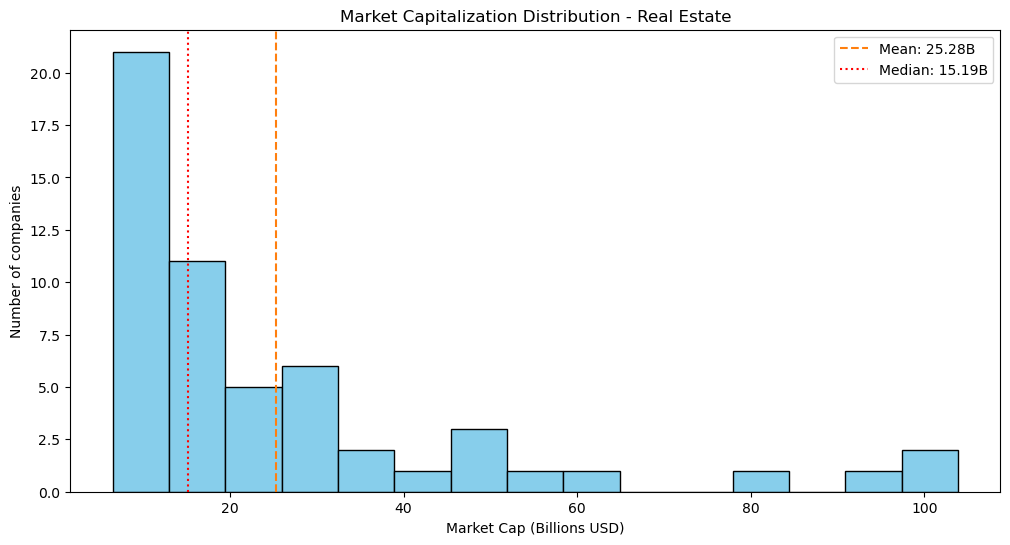

In [16]:
# Visualize the market cap distribution for the Real Estate sector.
# We add:
# - a median line
# - a mean line
# - clearer colors
# - an interpretive title and clear labels

mean_cap_b = real_estate_df['market_cap_b'].mean()
median_cap_b = real_estate_df['market_cap_b'].median()

plt.figure(figsize=(12,6))
plt.hist(real_estate_df['market_cap_b'], bins = 15, color = 'skyblue', edgecolor = 'black')

plt.axvline(mean_cap_b, color = '#FF7F0E', linestyle = '--', label=f'Mean: {mean_cap_b:.2f}B')
plt.axvline(median_cap_b, color = '#FF0000', linestyle = ':', label=f'Median: {median_cap_b:.2f}B')

plt.title('Market Capitalization Distribution - Real Estate')
plt.xlabel('Market Cap (Billions USD)')
plt.ylabel('Number of companies')
plt.legend()  # explain the box at the top right
plt.show()



## STEP 2

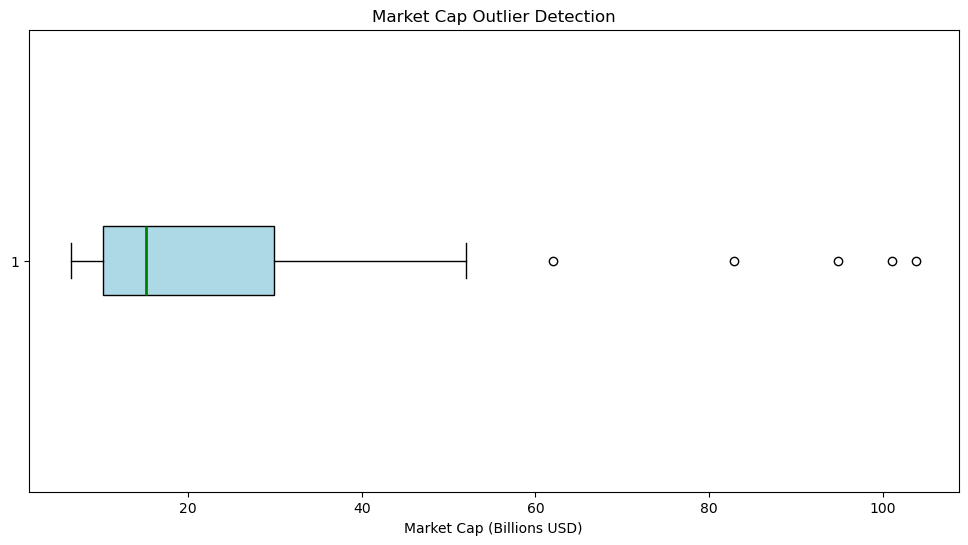

Original dataset size: 55 companies
Cleaned dataset size: 50 companies
Removed 5 outliers.


In [29]:
# Boxplot: Market cap.
# - Use the Interquartile Range (IQR) method to define the upper and lower bounds.
# - Filter out companies exceeding these boundaries.
# - Create a new, cleaned dataframe (real_estate_clean) for future steps.


plt.figure(figsize=(12, 6))
plt.boxplot(
    real_estate_df['market_cap_b'],
    vert =False, 
    patch_artist=True,
    boxprops=dict(
        facecolor='lightblue',
        color='black'
        ),
    medianprops=dict(
        color='green',
        linewidth=2
    ))

plt.title('Market Cap Outlier Detection')
plt.xlabel('Market Cap (Billions USD)')
plt.show()

# Calculating IQR and bounds

Q1 = real_estate_df['market_cap_b'].quantile(0.25)
Q3 = real_estate_df['market_cap_b'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Removing outliers

real_estate_clean = real_estate_df[
    (real_estate_df['market_cap_b'] >= lower_bound) &
    (real_estate_df['market_cap_b'] <= upper_bound)
].copy()

print(f"Original dataset size: {len(real_estate_df)} companies")
print(f"Cleaned dataset size: {len(real_estate_clean)} companies")
print(f"Removed {len(real_estate_df) - len(real_estate_clean)} outliers.")







## STEP 3

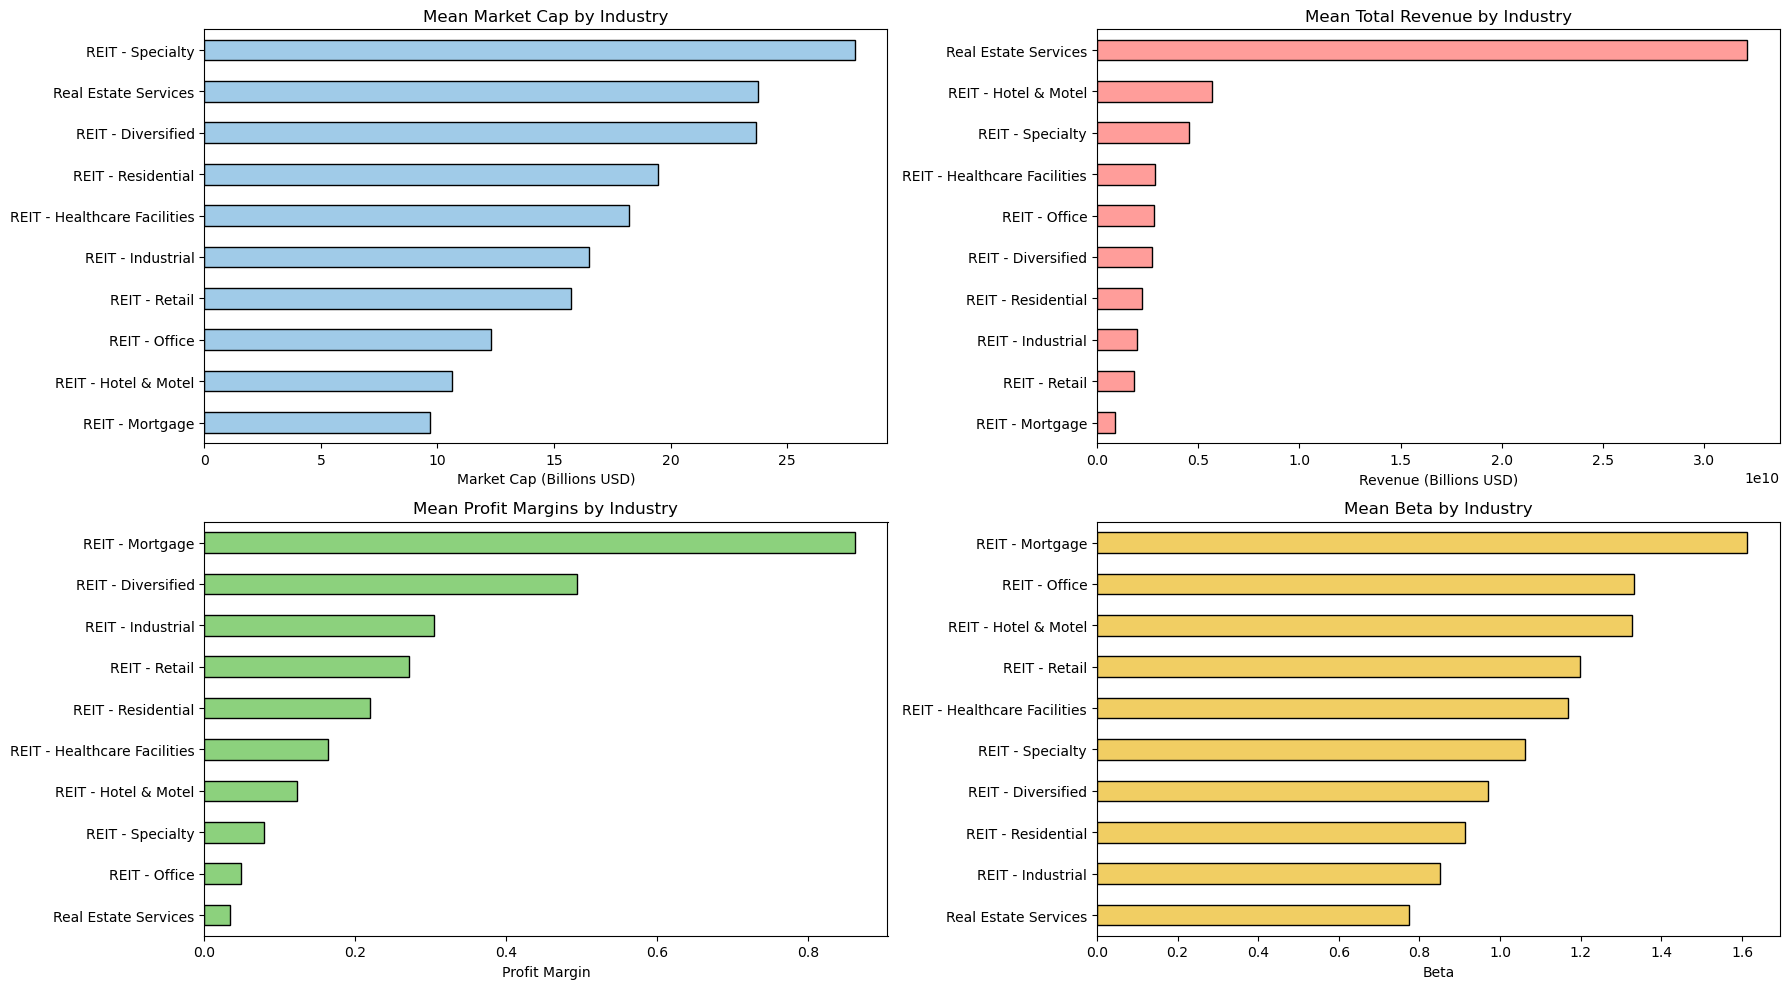

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

industry_means = real_estate_clean.groupby('industry')[['market_cap_b', 'total_revenue', 'profit_margins', 'beta']].mean()

industry_means['market_cap_b'].sort_values().plot(kind='barh', ax = axes[0, 0], color = '#A0CBE8', edgecolor = 'black')
axes[0, 0].set_title('Mean Market Cap by Industry')
axes[0, 0].set_xlabel('Market Cap (Billions USD)')
axes[0, 0].set_ylabel('')

industry_means['total_revenue'].sort_values().plot(kind='barh', ax= axes[0, 1], color = '#FF9D9A', edgecolor = 'black')
axes[0, 1].set_title('Mean Total Revenue by Industry')
axes[0, 1].set_xlabel('Revenue (Billions USD)')
axes[0, 1].set_ylabel('')

industry_means['profit_margins'].sort_values().plot(kind='barh', ax = axes[1, 0], color = '#8CD17D', edgecolor = 'black')
axes[1, 0].set_title('Mean Profit Margins by Industry')
axes[1, 0].set_xlabel('Profit Margin')
axes[1, 0].set_ylabel('')

industry_means['beta'].sort_values().plot(kind='barh', ax = axes[1,1], color = '#F1CE63', edgecolor = 'black')
axes[1, 1].set_title('Mean Beta by Industry')
axes[1, 1].set_xlabel('Beta')
axes[1, 1].set_ylabel('')

plt.tight_layout()
plt.show()

## STEP 4

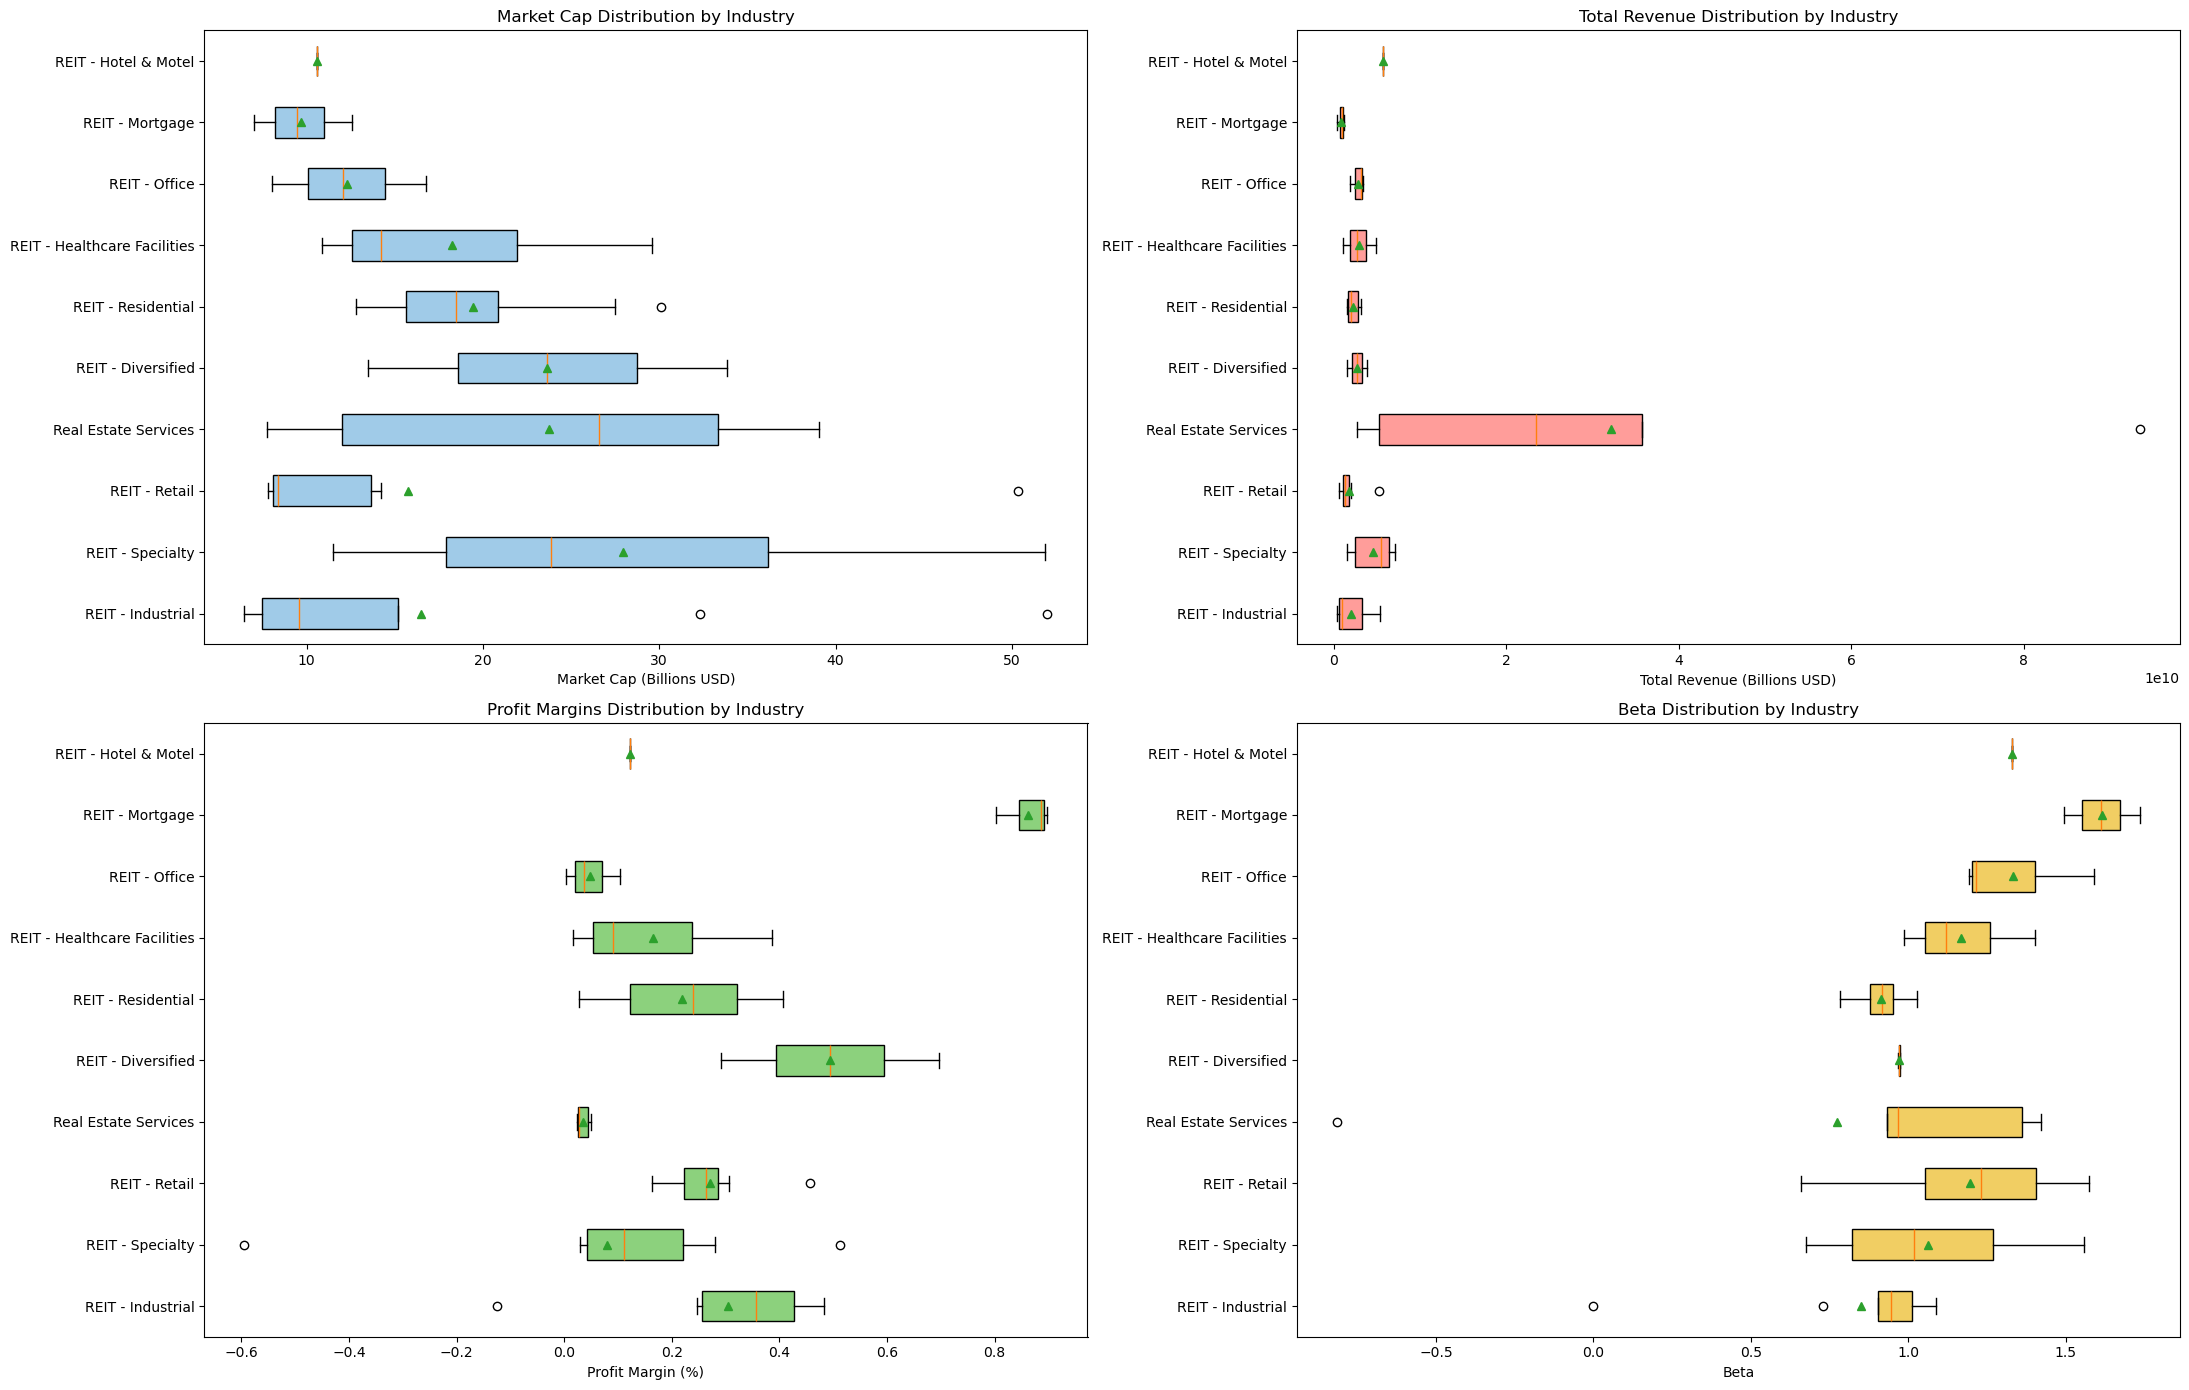

In [89]:
# 1. Prepariamo la griglia e fissiamo l'ordine delle industrie
fig, axes = plt.subplots(2, 2, figsize=(22, 14))

# Creiamo una lista fissa dei nomi delle industrie per averle tutte nello stesso ordine nei 4 grafici
industry_order = real_estate_clean['industry'].unique()

# --- METRICA 1: Market Cap ---
# Raccogliamo i dati: creiamo una lista di array, uno per ogni industria
data_cap = [real_estate_clean[real_estate_clean['industry'] == ind]['market_cap_b'].dropna().values for ind in industry_order]

# Disegniamo il boxplot orizzontale
axes[0, 0].boxplot(data_cap, labels=industry_order, vert=False, patch_artist=True, showmeans=True, boxprops={'facecolor': '#A0CBE8'})
axes[0, 0].set_title('Market Cap Distribution by Industry')
axes[0, 0].set_xlabel('Market Cap (Billions USD)')

# --- METRICA 2: Total Revenue ---
data_rev = [real_estate_clean[real_estate_clean['industry'] == ind]['total_revenue'].dropna().values for ind in industry_order]

axes[0, 1].boxplot(data_rev, labels=industry_order, vert=False, patch_artist=True, showmeans=True, boxprops={'facecolor': '#FF9D9A'})
axes[0, 1].set_title('Total Revenue Distribution by Industry')
axes[0, 1].set_xlabel('Total Revenue (Billions USD)')

# --- METRICA 3: Profit Margins ---
data_prof = [real_estate_clean[real_estate_clean['industry'] == ind]['profit_margins'].dropna().values for ind in industry_order]

axes[1, 0].boxplot(data_prof, labels=industry_order, vert=False, patch_artist=True, showmeans=True, boxprops={'facecolor': '#8CD17D'})
axes[1, 0].set_title('Profit Margins Distribution by Industry')
axes[1, 0].set_xlabel('Profit Margin (%)')

# --- METRICA 4: Beta ---
data_beta = [real_estate_clean[real_estate_clean['industry'] == ind]['beta'].dropna().values for ind in industry_order]

axes[1, 1].boxplot(data_beta, labels=industry_order, vert=False, patch_artist=True, showmeans=True, boxprops={'facecolor': '#F1CE63'})
axes[1, 1].set_title('Beta Distribution by Industry')
axes[1, 1].set_xlabel('Beta')

plt.tight_layout()
plt.show()





## STEP 5

### Industry selection

Based on the distribution analysis in te previous step, I selected the following three industries for further analysis:

* <span style="color: green;">**Real Estate Services:**</span> Selected for its anomalous volume-to-profit dynamic. It shows disproportionately high total revenue compared to the rest of the sector, but simultaneously exhibits the lowest profit margins.
* <span style="color: green;">**Reit - Mortgage:**</span> Selected for its clear dominance in operational efficiency. The profit margin distribution peaks near 80%, outperforming all other industries in the sector by a wide margin.
* <span style="color: green;">**REIT - Speciality:**</span> Selected as the sector's heavyweight. It holds the highest average Market Capitalization with a distribution skewed towards higher valuations.


*Industries Dropped:* Industries such as <span style="color: red;">REIT - Hotel & Motel</span> and <span style="color: red;">REIT - Office</span> were excluded as they consistently rank at the bottom for both Market Cap and Profit Margins, offering fewer interesting analytical dynamics for this specific comparison.

In [90]:
focus_industries = ['Real Estate Services', 'REIT - Mortgage', 'REIT - Specialty']
real_estate_focus = real_estate_clean[real_estate_clean['industry'].isin(focus_industries)].copy()

## STEP 6

Bubble Chart Encoding Choices

For this bubble chart, I selected the following visual encodings to analyze the relationship between risk, profitability and size.

* **X-Axis (Beta):** Represents the market risk and volatility of the company.
* **Y-Axis (Profit Margins):** Reveals the operational efficiency and profitability of the company.
* **Bubble Size (Market Capitalization):** Reflects the company's total market value, allowing for immediate visual identification of the largest players within the sector.
* **Bubble Color (Industry):** Identifies the sub-sector, allowing us to spot clustering patterns among different real estate categories.

The chart is divided into four quadrants using the median values of Beta and Profit Margins for the filtered dataset, categorizing companies into distinct risk-return profiles.


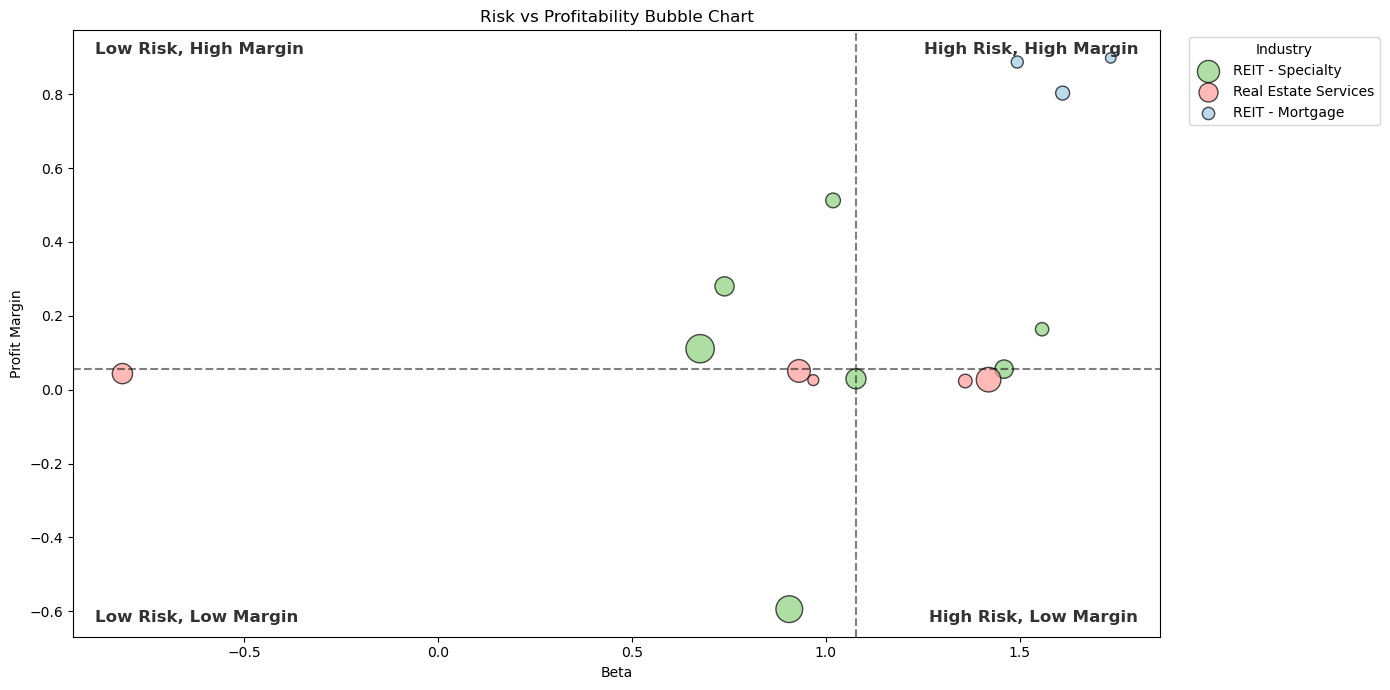

In [124]:
fig, ax = plt.subplots(figsize=(14, 7))

industries = real_estate_focus['industry'].unique()
colors = ['#8CD17D', '#FF9D9A', '#A0CBE8']

for i, ind in enumerate(industries):
    subset = real_estate_focus[real_estate_focus['industry'] == ind]
    ax.scatter(
        subset['beta'], 
        subset['profit_margins'], 
        s=subset['market_cap_b'] * 8,
        label=ind,
        color=colors[i],
        alpha=0.7,
        edgecolors='black'
        )
x_mid = real_estate_focus['beta'].median()
y_mid = real_estate_focus['profit_margins'].median()

ax.axvline(x=x_mid, color='black', linestyle='--', alpha=0.5)
ax.axhline(y=y_mid, color='black', linestyle='--', alpha=0.5)

ax.text(0.98, 0.98, 'High Risk, High Margin', transform=ax.transAxes, ha='right', va='top', fontsize=12, fontweight='bold', color='#333333')
ax.text(0.02, 0.98, 'Low Risk, High Margin', transform=ax.transAxes, ha='left', va='top', fontsize=12, fontweight='bold', color='#333333')
ax.text(0.02, 0.02, 'Low Risk, Low Margin', transform=ax.transAxes, ha='left', va='bottom', fontsize=12, fontweight='bold', color='#333333')
ax.text(0.98, 0.02, 'High Risk, Low Margin', transform=ax.transAxes, ha='right', va='bottom', fontsize=12, fontweight='bold', color='#333333')

ax.set_title('Risk vs Profitability Bubble Chart')
ax.set_xlabel('Beta')
ax.set_ylabel('Profit Margin')
ax.legend(title='Industry')

ax.legend(title='Industry', bbox_to_anchor=(1.02, 1), loc='upper left')


plt.tight_layout()
plt.show()

## STEP 7

[*********************100%***********************]  4 of 4 completed


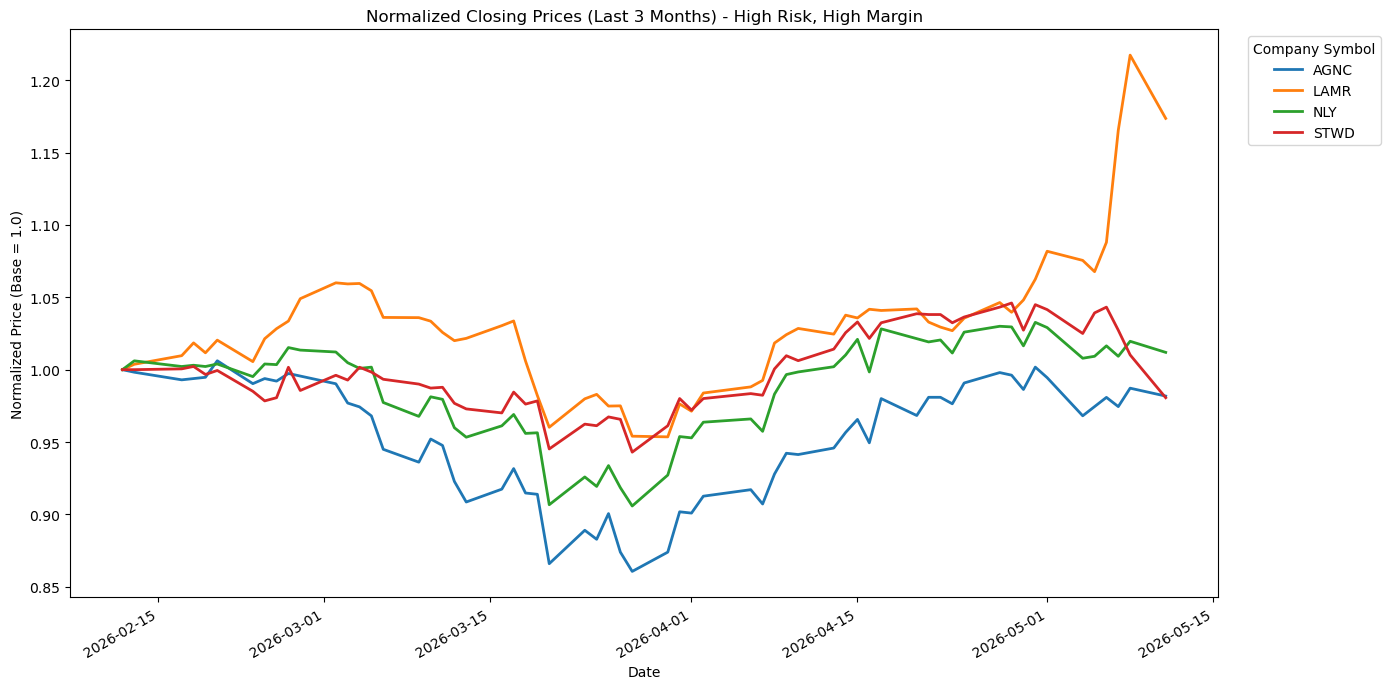

In [139]:

# We select the "High Risk, High Margin" quadrant.
# These Mortgage REITs exhibit high operational efficiency but are highly sensitive
# to market volatility (Beta > 1), making them ideal to analyze the impact of geopolitical shocks.
high_risk_high_margin = real_estate_focus[(real_estate_focus['beta'] > x_mid) & (real_estate_focus['profit_margins'] > y_mid)]

# Extract the top 10 companies by market capitalization within this specific quadrant
top_10_hrhm = high_risk_high_margin.nlargest(10, 'market_cap_b')

# Create a list of ticker symbols to be passed to the Yahoo Finance API
tickers = top_10_hrhm['symbol'].tolist()

# Download the last 3 months of daily closing prices for the selected tickers
prices = yf.download(tickers, period='3mo')['Close']

# Normalize the prices (Base = 1.0) by dividing all values by the first available price.
# This allows for a clean percentage-based performance comparison rather than absolute dollar values.
normalized_prices = prices / prices.iloc[0]

# Plot the normalized closing prices on a single chart
fig, ax = plt.subplots(figsize=(14, 7))
normalized_prices.plot(ax=ax, linewidth=2)

ax.set_title('Normalized Closing Prices (Last 3 Months) - High Risk, High Margin')
ax.set_xlabel('Date')
ax.set_ylabel('Normalized Price (Base = 1.0)')
ax.legend(title='Company Symbol', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()


# GEOPOLITICAL ANALYSIS (Strait of Hormuz)
# Looking at the chart over the last 3 months, these high-beta companies were visibly affected.
# # As the situation escalated, the chart shows a sharp drop in valuations, particularly bottoming out around late March.
# Currently, there are clear signs of recovery across the board, with some tickers exceeding their initial baseline,
# indicating the market is regaining confidence regarding these assets.


## STEP 8

[*********************100%***********************]  4 of 4 completed


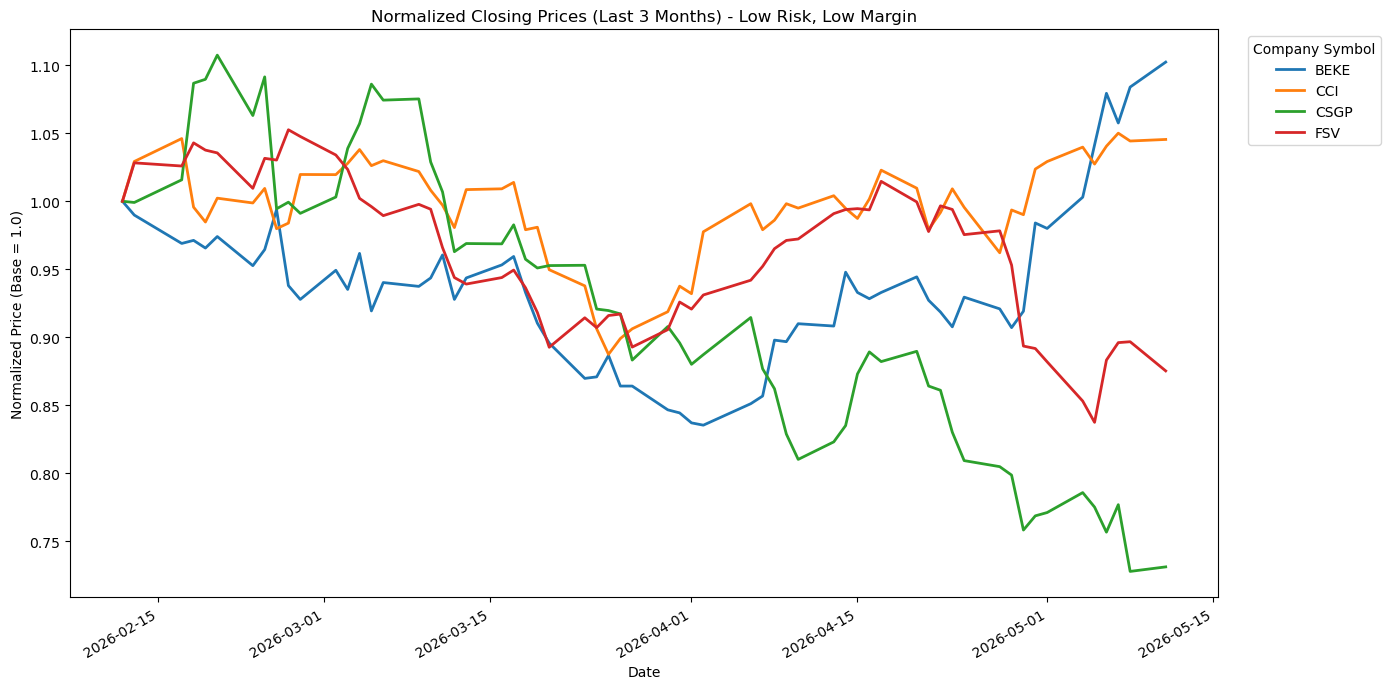

In [138]:
# We select the "Low Risk, Low Margin" quadrant for comparison.
# These companies have a low Beta (below the median), meaning they are theoretically
# less volatile and more resilient to market shocks compared to the High Risk group.
low_risk_low_margin = real_estate_focus[(real_estate_focus['beta'] < x_mid) & (real_estate_focus['profit_margins'] < y_mid)]

# Extract the top 10 companies by market capitalization within this quadrant
top_10_lrlm = low_risk_low_margin.nlargest(10, 'market_cap_b')

# Create a list of ticker symbols for the Yahoo Finance API
tickers_lrlm = top_10_lrlm['symbol'].tolist()

# Download the last 3 months of daily closing prices for this new group
prices_lrlm = yf.download(tickers_lrlm, period='3mo')['Close']

# Normalize the prices (Base = 1.0) on the first available trading day for comparison
normalized_prices_lrlm = prices_lrlm / prices_lrlm.iloc[0]

# Plot the normalized closing prices on a single chart
fig, ax = plt.subplots(figsize=(14, 7))
normalized_prices_lrlm.plot(ax=ax, linewidth=2)

ax.set_title('Normalized Closing Prices (Last 3 Months) - Low Risk, Low Margin')
ax.set_xlabel('Date')
ax.set_ylabel('Normalized Price (Base = 1.0)')
ax.legend(title='Company Symbol', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()


# COMPARISON ANALYSIS
# Compared to the High Risk group in Step 7, these Low Risk companies reacted completely differently to the geopolitical context.
# During the tensions in the Strait of Hormuz, they did not act as a unified, resilient block.
# Instead of a correlated V-shaped crash, they showed highly disjointed and individualistic patterns
# (CSGP dropping continuously, while BEKE spiked late).
# The quadrant logic perfectly explains this behavior: using Beta as the x-axis successfully isolated
# a group of assets with low market correlation. Therefore, sudden macroeconomic shocks do not drag them
# all down together; rather, their internal business dynamics dominate their price action.
